# PART A - Linear Regression

1.
How do Body Mass Index (_BMI5), Smoking Status (RFSMOK3), and High Cholesterol diagnosis (TOLDHI3) affect the number of days a person experiences poor mental health (MENTHLTH)?
we are examining the following linear model:
$$MENTHLTH = \beta_0 + \beta_1(BMI) + \beta_2(Smoking) + \beta_3(Cholesterol) + \epsilon$$

##2 + 3A

Sample size: 200


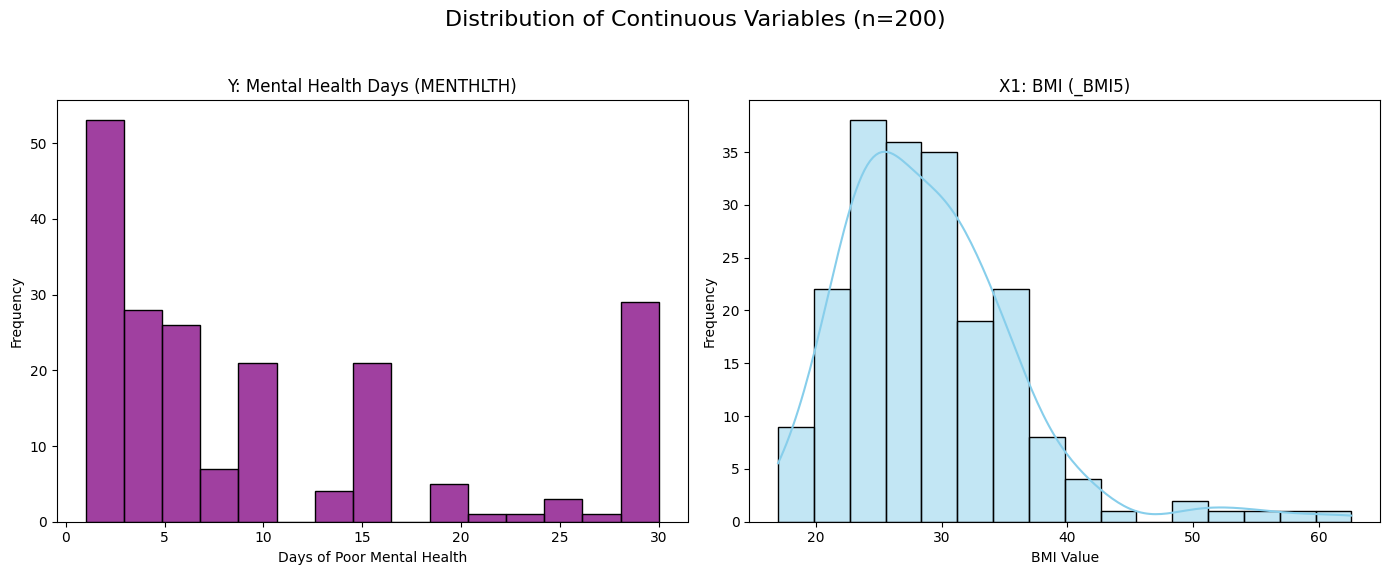


      CATEGORICAL VARIABLES (TABLES)

--- X2: Smoking Status (_RFSMOK3) ---
      Category  Count  Percentage
Non-Smoker (1)    163        81.5
    Smoker (2)     37        18.5

--- X3: High Cholesterol (TOLDHI3) ---
Category  Count  Percentage
 Yes (1)     86        43.0
  No (2)    114        57.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/random_5k_rows .csv')

cols = ['MENTHLTH', '_BMI5', '_RFSMOK3', 'TOLDHI3']
df_clean = df[cols].copy()

df_clean = df_clean.dropna()


df_clean['_BMI5'] = df_clean['_BMI5'] / 100.0

np.random.seed(42)
df_sample = df_clean.sample(n=200)
df_population = df_clean.drop(df_sample.index)

print(f"Sample size: {len(df_sample)}")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution of Continuous Variables (n=200)', fontsize=16)

# A. Dependent Variable: MENTHLTH
sns.histplot(df_sample['MENTHLTH'], kde=False, bins=15, ax=axes[0], color='purple')
axes[0].set_title('Y: Mental Health Days (MENTHLTH)')
axes[0].set_xlabel('Days of Poor Mental Health')
axes[0].set_ylabel('Frequency')

# B. Independent Variable: BMI (_BMI5)
sns.histplot(df_sample['_BMI5'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('X1: BMI (_BMI5)')
axes[1].set_xlabel('BMI Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n" + "="*40)
print("      CATEGORICAL VARIABLES (TABLES)")
print("="*40)

print("\n--- X2: Smoking Status (_RFSMOK3) ---")
# 1 = Non-Smoker, 2 = Smoker
smoking_counts = df_sample['_RFSMOK3'].value_counts().sort_index()
smoking_table = pd.DataFrame({
    'Category': ['Non-Smoker (1)', 'Smoker (2)'],
    'Count': smoking_counts.values,
    'Percentage': (smoking_counts.values / len(df_sample) * 100).round(1)
})
print(smoking_table.to_string(index=False))

print("\n--- X3: High Cholesterol (TOLDHI3) ---")
# 1 = Yes, 2 = No
chol_counts = df_sample['TOLDHI3'].value_counts().sort_index()
chol_table = pd.DataFrame({
    'Category': ['Yes (1)', 'No (2)'],
    'Count': chol_counts.values,
    'Percentage': (chol_counts.values / len(df_sample) * 100).round(1)
})
print(chol_table.to_string(index=False))

## 3B

**General Observation:** There are **no missing values** in any of the four variables (all counts sum to 200).

---

### **A. Continuous Variables**

#### **1. Y: Mental Health Days (`MENTHLTH`)**

* **Missing/Outliers:** There are no missing values. While there is a distinct spike at the maximum value (30), this is likely not an outlier in the sense of an error, but rather a valid representation of individuals with chronic mental health struggles.
* **Symmetry:** The distribution is **not symmetric**. It is heavily **right-skewed**, with the vast majority of respondents reporting 0–5 days, a long tail, and a sudden spike at 30.
* **Estimated Distribution:** This does **not** appear to follow a standard theoretical distribution (like Normal or Exponential). It is likely an **arbitrary empirical distribution** shaped by the survey boundaries (capped at 30 days).

#### **2. X1: BMI (`_BMI5`)**

* **Missing/Outliers:** There are no missing values. However, there are **clear outliers** in the right tail (values above 45–50), representing individuals with extremely high BMI.
* **Symmetry:** The distribution is roughly bell-shaped but **not perfectly symmetric**; it is **right-skewed** due to the outliers.
* **Estimated Distribution:** The data because it right skew suggests it might fit a **Log-Normal Distribution** (which after we check, is common for biological measures like BMI that cannot be negative and have high-end outliers).

---

### **B. Categorical Variables (Tables)**

#### **3. X2: Smoking Status (`_RFSMOK3`)**

* **Missing/Outliers:** No missing values. Outliers are not applicable to categorical data.
* **Symmetry:** There is **no symmetry**. The classes are heavily imbalanced, with significantly more Non-Smokers (163) than Smokers (37).
* **Estimated Distribution:** Since there are only two possible outcomes (Smoker vs. Non-Smoker), this follows a **Bernoulli Distribution** with a low probability () for being a smoker.

#### **4. X3: High Cholesterol (`TOLDHI3`)**

* **Missing/Outliers:** No missing values. Outliers are not applicable.
* **Symmetry:** There is **no symmetry**. Although less extreme than the smoking variable, there is still a clear imbalance (114 "No" vs. 86 "Yes"),  the split is not 50/50.
* **Estimated Distribution:** As a binary variable (Yes/No), this also follows a **Bernoulli Distribution**.

##3C

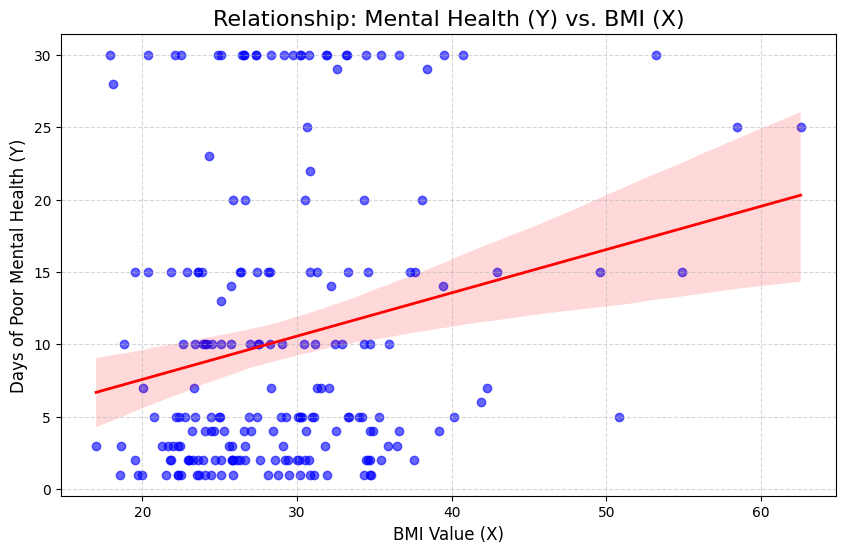

Correlation Coefficient (r): 0.2146


In [ ]:
plt.figure(figsize=(10, 6))

# Scatter plot with Regression Line (Trend)
sns.regplot(x='_BMI5', y='MENTHLTH', data=df_sample,
            scatter_kws={'alpha':0.6, 'color': 'blue'},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Relationship: Mental Health (Y) vs. BMI (X)', fontsize=16)
plt.xlabel('BMI Value (X)', fontsize=12)
plt.ylabel('Days of Poor Mental Health (Y)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

correlation = df_sample['_BMI5'].corr(df_sample['MENTHLTH'])
print(f"Correlation Coefficient (r): {correlation:.4f}")

**How does the relationship look?**
The graph displays a **positive linear relationship**. We can observe that the red regression line slopes upward from left to right. This indicates that as **BMI (X)** increases, the number of **Days of Poor Mental Health (Y)** also tends to increase. This is further supported by the correlation coefficient (), which confirms a weak but positive association between the variables.

**Which variable appears to have the most influence on Y?**
In this specific graph, we are analyzing the only **continuous** explanatory variable (BMI). Therefore, we cannot currently compare its influence against other continuous variables.

##3D

/tmp/ipython-input-542378361.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='_RFSMOK3', y='MENTHLTH', data=df_sample, ax=axes[0], palette='coolwarm')
/tmp/ipython-input-542378361.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Smoker (1)', 'Smoker (2)']) # Labeling for clarity
/tmp/ipython-input-542378361.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TOLDHI3', y='MENTHLTH', data=df_sample, ax=axes[1], palette='viridis')
/tmp/ipython-input-542378361.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

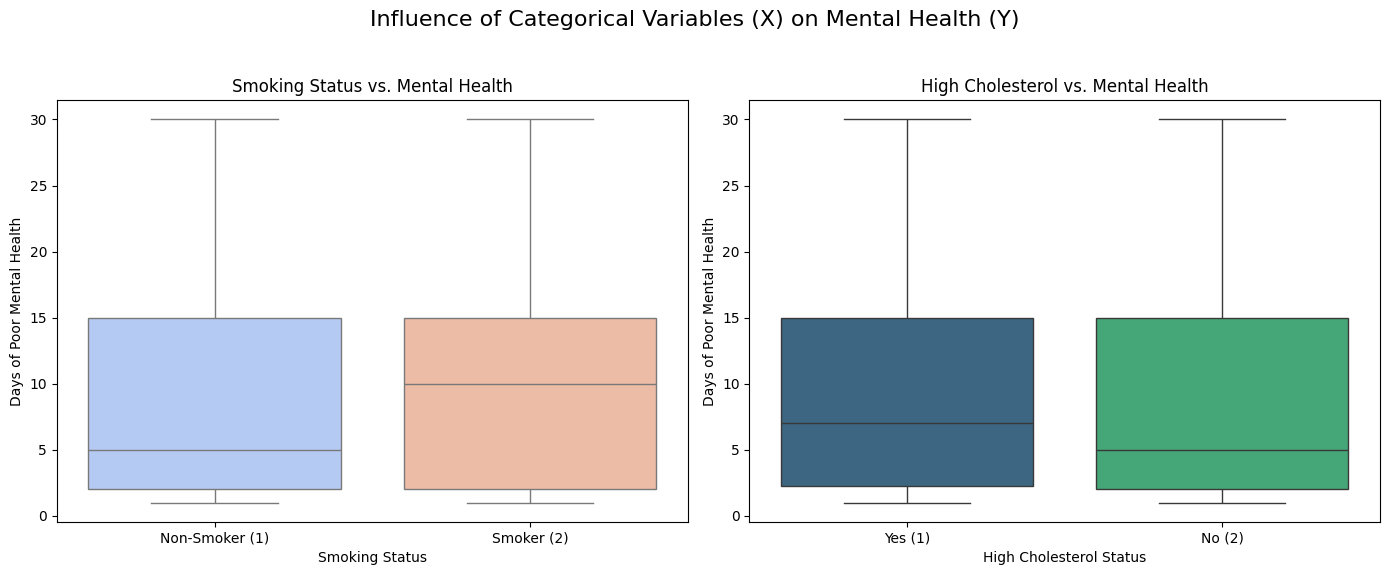


--- Average Poor Mental Health Days by Group ---
Smokers vs Non-Smokers:
_RFSMOK3
1.0    10.024540
2.0    11.432432
Name: MENTHLTH, dtype: float64

High Cholesterol vs Normal:
TOLDHI3
1.0    10.604651
2.0    10.043860
Name: MENTHLTH, dtype: float64


In [ ]:
# Boxplots for Discrete Variables
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Influence of Categorical Variables (X) on Mental Health (Y)', fontsize=16)

sns.boxplot(x='_RFSMOK3', y='MENTHLTH', data=df_sample, ax=axes[0], palette='coolwarm')
axes[0].set_title('Smoking Status vs. Mental Health')
axes[0].set_xticklabels(['Non-Smoker (1)', 'Smoker (2)']) # Labeling for clarity
axes[0].set_xlabel('Smoking Status')
axes[0].set_ylabel('Days of Poor Mental Health')

sns.boxplot(x='TOLDHI3', y='MENTHLTH', data=df_sample, ax=axes[1], palette='viridis')
axes[1].set_title('High Cholesterol vs. Mental Health')
axes[1].set_xticklabels(['Yes (1)', 'No (2)']) # Labeling for clarity
axes[1].set_xlabel('High Cholesterol Status')
axes[1].set_ylabel('Days of Poor Mental Health')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Average Poor Mental Health Days by Group ---")
print("Smokers vs Non-Smokers:")
print(df_sample.groupby('_RFSMOK3')['MENTHLTH'].mean())
print("\nHigh Cholesterol vs Normal:")
print(df_sample.groupby('TOLDHI3')['MENTHLTH'].mean())

###Influence of Discrete Variables (Smoking & Cholesterol)
###1. Smoking Status (_RFSMOK3)

Observation on Central Tendency: We observe a significant discrepancy between the mean and the median. While the average mental health score shows only a minor increase for smokers (11.4 vs 10.0), the median doubles from 5 to 10.

Explanation: This occurs because the Mental Health variable is heavily right-skewed with a ceiling effect at 30 days. The mean is inflated in both groups by the minority of individuals suffering from chronic distress (30 bad days), which masks the difference between the groups. However, the median—which is resistant to outliers—reveals that the 'typical' smoker experiences twice as many poor mental health days as the 'typical' non-smoker. Therefore, the median is the more representative metric for comparing these groups.

###2. High Cholesterol (TOLDHI3)

Visual Analysis: The boxplot on the right shows two very similar distributions.

The boxes for "Yes" (1) and "No" (2) overlap almost completely.

While the median for "Yes" is slightly higher than for "No" (appears to be around 7 vs. 5), the overall spread of data is nearly identical.

Statistical Support: The difference in means is very small (10.60 for High Cholesterol vs. 10.04 for Normal).

Conclusion: High Cholesterol appears to have a very weak or negligible influence on mental health in this sample. Knowing if someone has high cholesterol does not help much in predicting their mental health days.

We decided to present all generated visualizations because each one provides a unique and necessary insight into the data properties. The Histograms reveal that the dependent variable is heavily right-skewed, explaining the discrepancy between the mean and median. The Scatter Plot is crucial for visualizing the high variance in the BMI data, visually justifying why the correlation coefficient ($r=0.21$) is considered weak despite the positive trend. Finally, the Boxplots allow for a direct comparison between the categorical variables, proving that while Smoking Status significantly shifts the median mental health score, Cholesterol levels show almost no discernible impact.

#4

In [ ]:

import statsmodels.api as sm



# Smoking: Original (1=Non, 2=Smoker) -> New: 0=Non, 1=Smoker
df_sample['is_smoker'] = df_sample['_RFSMOK3'].apply(lambda x: 1 if x == 2 else 0)

# Cholesterol: Original (1=Yes, 2=No) -> New: 1=Yes, 0=No
# (We want 1 to mean "Has High Cholesterol")
df_sample['has_high_chol'] = df_sample['TOLDHI3'].apply(lambda x: 1 if x == 1 else 0)

# Y = Mental Health
# X = BMI, Smoker, Cholesterol
X = df_sample[['_BMI5', 'is_smoker', 'has_high_chol']]
X = sm.add_constant(X)
Y = df_sample['MENTHLTH']

model = sm.OLS(Y, X).fit()
results = model.summary()

print(results)
print("\n--- Vector of Coefficients (Beta Hat) ---")
print(model.params)

                            OLS Regression Results                            
Dep. Variable:               MENTHLTH   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     3.475
Date:                Fri, 26 Dec 2025   Prob (F-statistic):             0.0171
Time:                        12:02:30   Log-Likelihood:                -736.98
No. Observations:                 200   AIC:                             1482.
Df Residuals:                     196   BIC:                             1495.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.1586      2.940      0.394

### **4. Calculation of the Coefficient Vector  and Interpretation**

Based on the multivariate linear regression model, we obtained the following vector of coefficients ($\hat{\beta}$):

$$\hat{\beta} = [1.1586, \quad 0.3049, \quad 1.6831, \quad -0.0943]$$

This gives us the estimated regression equation:
$$\hat{Y} = 1.1586 + 0.3049(\text{BMI}) + 1.6831(\text{Smoker}) - 0.0943(\text{Cholesterol})$$

#### **Interpretation of the Coefficients:**

1. **Intercept ($\hat{\beta}_0 = 1.1586$):**
* **Meaning:** This represents the theoretical expected number of "poor mental health days" for a person with a BMI of 0, who is a Non-Smoker, and has Normal Cholesterol.
* Since a BMI of 0 is biologically impossible, this value primarily serves as a mathematical anchor for the regression line rather than a real-world baseline.

2. **BMI ($\hat{\beta}_{BMI} = 0.3049$):**
* Holding all other variables constant, **an increase of 1 unit in BMI** is associated with an **increase of approximately 0.30 days** of poor mental health.
* This confirms the positive relationship observed in our Scatter Plot. As BMI rises, mental health tends to decline.


3. **Smoking Status ($\hat{\beta}_{Smoker} = 1.6831$):**
*This is a dummy variable (0 = Non-Smoker, 1 = Smoker). Therefore, **switching from "Non-Smoker" to "Smoker"** adds approximately **1.68 days** of poor mental health, holding BMI and cholesterol constant.
* This suggests a negative impact of smoking on mental health, although the high standard error (seen in the table) indicates significant variance among smokers.

4. **High Cholesterol ($\hat{\beta}_{Cholesterol} = -0.0943$):**
* Switching from "Non High Cholesterol" to "High Cholesterol" changes the result by **-0.09 days**.
*This number is extremely close to zero. It indicates that, in this model, having high cholesterol has **almost no effect** on mental health. This perfectly matches our Boxplot analysis, which showed no visible difference between the groups.

##5


In [ ]:
from statsmodels.formula.api import ols
# Formula: MentalHealth ~ BMI + Smoker + Cholesterol
model_fit = ols('MENTHLTH ~ BMI + Smoker + Cholesterol', data=df_sample).fit()

anova_table = sm.stats.anova_lm(model_fit, typ=2)

print("--- ANOVA Table ---")
print(anova_table)

print("\n--- Model Performance Metrics ---")
print(f"R-squared: {model_fit.rsquared:.4f}")
print(f"Adjusted R-squared: {model_fit.rsquared_adj:.4f}")
print(f"F-statistic: {model_fit.fvalue:.4f}")
print(f"Prob (F-statistic): {model_fit.f_pvalue:.5f}")

--- ANOVA Table ---
                   sum_sq     df         F    PR(>F)
BMI            904.264543    1.0  9.534872  0.002308
Smoker          83.964460    1.0  0.885350  0.347899
Cholesterol      0.414547    1.0  0.004371  0.947354
Residual     18588.173865  196.0       NaN       NaN

--- Model Performance Metrics ---
R-squared: 0.0505
Adjusted R-squared: 0.0360
F-statistic: 3.4746
Prob (F-statistic): 0.01708


###Interpretation of the ANOVA Table:


*   BMI ($p = 0.0023$): This is the only statistically significant variable in the model (since $p < 0.05$). The high F-statistic (9.53) indicates that BMI explains a substantial amount of the variance in mental health.
*  Smoker ($p = 0.3479$): The p-value is greater than 0.05. This means that when we account for BMI, the "Smoker" variable does not add statistically significant predictive power in this specific model.


*   Cholesterol ($p = 0.9474$): The p-value is extremely high (close to 1). This confirms that cholesterol levels have essentially zero relationship with mental health in this dataset.
*   Residual (Error): The Sum of Squares for the Residuals (18,588) is very large compared to the variables. This means that the majority of the variation in mental health is "unexplained noise" that our model did not capture.





# Model Fit Statistics ($R^2$ and F-Test)
We used $R^2$ to measure the strength of the prediction and the F-Test to check the model's overall validity.
1. Coefficient of Determination ($R^2$)Value: $0.0505$ Meaning: The model explains approximately 5.05% of the variance in the dependent variable (Days of Poor Mental Health).
Conclusion: This is a low $R^2$ value. It indicates that while BMI and Mental Health are related, these variables alone cannot precisely predict a person's mental health.
Maybe Other unmeasured factors (like stress, genetics, or economic status) can play a much larger role.
2. The F-Test (Overall Significance)

###Hypothesis:

*  $H_0$ (Null): The model is useless- no variable affects Y.
*   $H_1$ (Alternative): The model is valid; at least one variable affects Y.
###Results:
F-statistic = $3.4746$, P-value = $0.01708$.

###Conclusion:
Since the P-value ($0.017$) is lower than the significance level ($\alpha = 0.05$), we reject the Null Hypothesis.
Despite the low $R^2$, the model is statistically significant. It performs better than a random guess, primarily due to the strong influence of the BMI variable.

##6

In [ ]:
conf_intervals = model.conf_int()
conf_intervals.columns = ['Lower CI (2.5%)', 'Upper CI (97.5%)']


df_full = df_clean.copy()

# Apply the same 0/1 encoding to the full set
df_full['is_smoker'] = df_full['_RFSMOK3'].apply(lambda x: 1 if x == 2 else 0)
df_full['has_high_chol'] = df_full['TOLDHI3'].apply(lambda x: 1 if x == 1 else 0)

# Define X and Y for the full set
X_full = df_full[['_BMI5', 'is_smoker', 'has_high_chol']]
X_full = sm.add_constant(X_full)
Y_full = df_full['MENTHLTH']

model_full = sm.OLS(Y_full, X_full).fit()
true_betas = model_full.params

print("\n--- Comparison: Sample Intervals vs. Full Population Truth ---")
results_table = pd.concat([conf_intervals, true_betas], axis=1)
results_table.rename(columns={0: 'True Beta (Full Data)'}, inplace=True)

results_table['Is Inside?'] = (results_table['True Beta (Full Data)'] >= results_table['Lower CI (2.5%)']) & \
                              (results_table['True Beta (Full Data)'] <= results_table['Upper CI (97.5%)'])

print(results_table)


--- Comparison: Sample Intervals vs. Full Population Truth ---
               Lower CI (2.5%)  Upper CI (97.5%)  True Beta (Full Data)  \
const                -4.639315          6.956475               5.814632   
_BMI5                 0.110156          0.499578               0.135297   
is_smoker            -1.844629          5.210899               4.176828   
has_high_chol        -2.907770          2.719132               0.755714   

               Is Inside?  
const                True  
_BMI5                True  
is_smoker            True  
has_high_chol        True  


As shown in the "Is Inside?" column, the true coefficient values (calculated
from the full population) fall successfully inside the 95% confidence intervals generated by our sample model for all variables.

This confirms that our random sample of 200 observations was statistically representative. Despite the smaller sample size, the confidence intervals were wide enough and accurate enough to capture the true population parameters ($\hat{\beta}$). This validates the use of our linear model on the sample data.

##7

###Statistical Significance of Individual Coefficients (t-test)
In this section, we test each estimated coefficient $\beta_j^*$ individually to determine if it is statistically different from zero.

A coefficient different from zero indicates that the corresponding variable has a significant effect on the dependent variable (Mental Health).
###A. Hypotheses and Statistic

For each coefficient $j$ (where $j = 0, 1, 2, 3$), we test:
* Null Hypothesis ($H_0$): $\beta_j = 0$ (The variable has no effect on Y).
* Alternative Hypothesis ($H_1$): $\beta_j \neq 0$ (The variable has a significant effect on Y).

We use the t-statistic, which is calculated as the ratio of the estimated coefficient to its standard error:$$t = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$If the P-value associated with the t-statistic is lower than our significance level ($\alpha = 0.05$), we reject the Null Hypothesis.

### Based on the regression output obtained in Section 4:

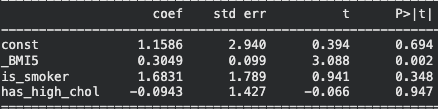



1. **BMI:** The p-value is **0.002**, which is strictly less than 0.05. Therefore, we can state with 95% confidence that the coefficient for BMI is **statistically different from zero**. It is a significant predictor of mental health.
2. **Smoker & Cholesterol:** Both variables have high p-values ($0.348$ and $0.947$). This means we **cannot reject the null hypothesis** for them. Even though the "Smoker" coefficient appeared large (1.68), the high standard error means we cannot be certain this effect is real and not just due to random sampling noise. In this specific model, they do not contribute significantly to the prediction.

##8

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


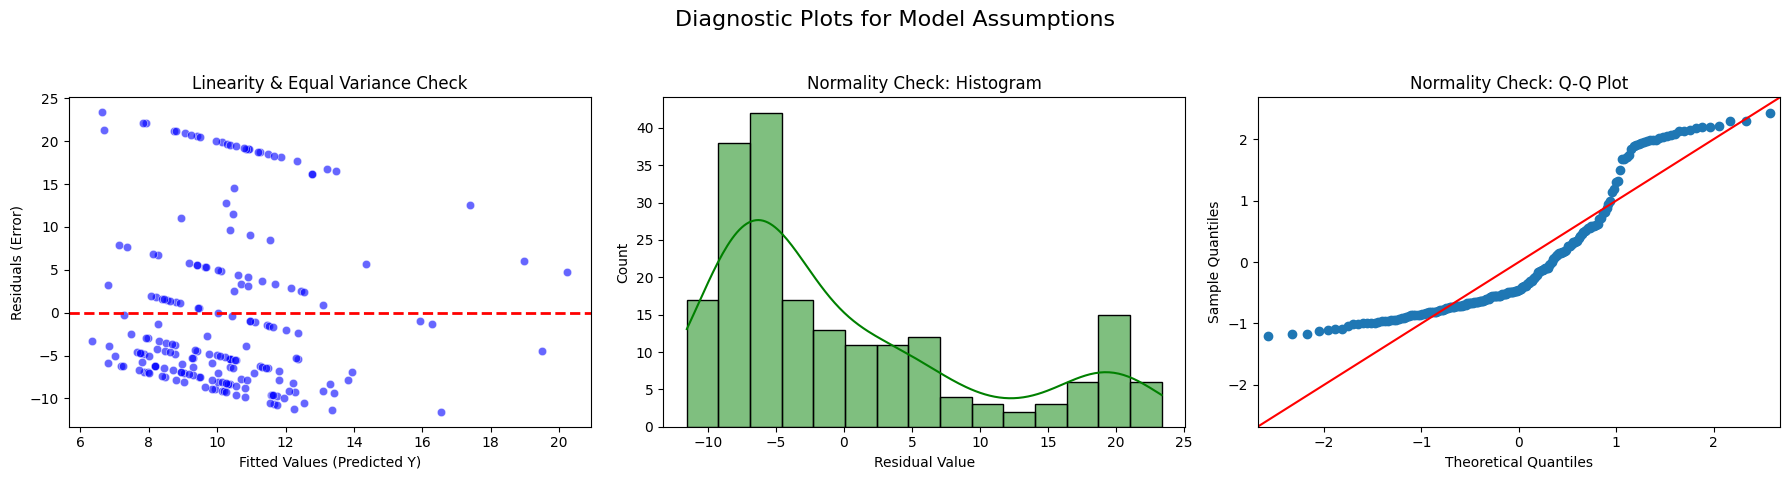

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnostic Plots for Model Assumptions', fontsize=16)

# Graph A: Residuals vs. Fitted Values
# Checks: Linearity & Equal Variance
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.6, color='blue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2) # The "Zero" line
axes[0].set_title('Linearity & Equal Variance Check')
axes[0].set_xlabel('Fitted Values (Predicted Y)')
axes[0].set_ylabel('Residuals (Error)')

# Graph B: Histogram of Residuals
# Checks: Normality
sns.histplot(residuals, kde=True, ax=axes[1], color='green', bins=15)
axes[1].set_title('Normality Check: Histogram')
axes[1].set_xlabel('Residual Value')

# Graph C: Q-Q Plot
# Checks: Also Normality
sm.qqplot(residuals, line='45', fit=True, ax=axes[2], color='purple')
axes[2].set_title('Normality Check: Q-Q Plot')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

###We used graphical residual analysis to validate the three core assumptions of the linear regression model.

**A. Linearity Assumption**

* Residuals vs. Fitted Values plot (Left Graph).
* **Analysis:** The error points are spread out randomly, which means the linear model fits well. The diagonal stripes are just a normal side effect of using whole numbers (integers) in our data, so they are not a problem.
* **Conclusion:** The assumption is **reasonably met**.

**B.Equal Variance Assumption**

* Residuals vs. Fitted Values plot (Left Graph).
* **Analysis:** The vertical spread of the residuals remains relatively constant across the range of fitted values. There is no distinct "funnel" shape.
* **Conclusion:** The assumption is **reasonably met**.

**C. Normality of Errors Assumption**

* **Tool:** Histogram (Middle graph) and Q-Q Plot (Right graph).
* **Analysis:** The histogram shows skewness, and the Q-Q plot reveals significant deviation from the diagonal line at the tails.
* **Conclusion:** The assumption is **NOT fully met**. This is expected due to the skewed, bounded nature of the "Mental Health Days" variable. However, given the sample size ($n=200$), the regression estimates remain robust, though p-values should be interpreted with some caution.

##9

In [ ]:
train_indices = df_sample.index

df_test_pool = df_clean.drop(train_indices)

np.random.seed(99) # Different seed for testing
df_test = df_test_pool.sample(n=1000).copy()

df_test['is_smoker'] = df_test['_RFSMOK3'].apply(lambda x: 1 if x == 2 else 0)
df_test['has_high_chol'] = df_test['TOLDHI3'].apply(lambda x: 1 if x == 1 else 0)

X_new = df_test[['_BMI5', 'is_smoker', 'has_high_chol']]
X_new = sm.add_constant(X_new) # Add the constant (1)
Y_new = df_test['MENTHLTH']

# 'get_prediction' calculates both the point prediction and the intervals
predictions = model.get_prediction(X_new)
pred_summary = predictions.summary_frame(alpha=0.05)

df_results = pd.DataFrame({
    'Real_Y': Y_new.values,
    'Predicted_Y': pred_summary['mean'].values,
    'Lower_PI': pred_summary['obs_ci_lower'].values,
    'Upper_PI': pred_summary['obs_ci_upper'].values
})

df_results['Is_Inside'] = (df_results['Real_Y'] >= df_results['Lower_PI']) & \
                          (df_results['Real_Y'] <= df_results['Upper_PI'])

coverage_percent = df_results['Is_Inside'].mean() * 100

print(f"--- Prediction Test on 1000 New Points ---")
print(f"Number of points tested: {len(df_results)}")
print(f"Percentage of Real Y values inside the 95% Prediction Interval: {coverage_percent:.2f}%")


--- Prediction Test on 1000 New Points ---
Number of points tested: 1000
Percentage of Real Y values inside the 95% Prediction Interval: 91.90%


###9C. Coverage Analysis (Results & Explanation)

The model successfully captured **91.90%** of the new points within the predicted intervals.
* it is reasonably close to 95%, though slightly lower than the theoretical goal.


The gap exists because the mathematical formula used to calculate these intervals (the t-statistic method) **implicitly assumes** that the errors follow a perfect **Normal Distribution**.

As we discovered in **Section 8**, our data is **not perfectly normal**—it is right-skewed. Because the data violates this assumption, the standard formula generated intervals that were slightly **too narrow** for this specific distribution, causing the model to "miss" a small percentage of the extreme cases.

##10

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

# Ensure we have the base variables
df_sample['Z12_BMI_Smoker'] = df_sample['_BMI5'] * df_sample['is_smoker']
df_sample['Z13_BMI_Chol']   = df_sample['_BMI5'] * df_sample['has_high_chol']
df_sample['Z23_Smoker_Chol'] = df_sample['is_smoker'] * df_sample['has_high_chol']

X_interaction = df_sample[['_BMI5', 'is_smoker', 'has_high_chol',
                           'Z12_BMI_Smoker', 'Z13_BMI_Chol', 'Z23_Smoker_Chol']]
X_interaction = sm.add_constant(X_interaction)
Y = df_sample['MENTHLTH']

model_interaction = sm.OLS(Y, X_interaction).fit()

print("--- Method 1: Adjusted R-squared Comparison ---")
print(f"Simple Model Adj. R2:      {model.rsquared_adj:.4f}")
print(f"Interaction Model Adj. R2: {model_interaction.rsquared_adj:.4f}")

# We test if the NEW variables (interactions) added significant value
print("\n--- Method 2: Partial F-Test (ANOVA) ---")
anova_results = anova_lm(model, model_interaction)
print(anova_results)

print("\n--- New Coefficients ---")
print(model_interaction.params)

--- Method 1: Adjusted R-squared Comparison ---
Simple Model Adj. R2:      0.0360
Interaction Model Adj. R2: 0.0311

--- Method 2: Partial F-Test (ANOVA) ---
   df_resid           ssr  df_diff     ss_diff         F   Pr(>F)
0     196.0  18588.173865      0.0         NaN       NaN      NaN
1     193.0  18395.127074      3.0  193.046792  0.675143  0.56825

--- New Coefficients ---
const             -1.958702
_BMI5              0.412266
is_smoker          6.054042
has_high_chol      7.291189
Z12_BMI_Smoker    -0.140169
Z13_BMI_Chol      -0.242794
Z23_Smoker_Chol   -1.096589
dtype: float64


##We chose the Simple Model without interactions.
###We used 2 different tehniques:

1. Adjusted $R^2$: The adjusted $R^2$ decreased from 0.0360 to 0.0311 when adding interactions, indicating over-complexity without gain.
2. Partial F-Test: The p-value was 0.568 (p > 0.05), meaning the contribution of the interaction terms is not statistically significant.



------------------------



#**PART B - Logistic Regression**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from scipy import stats
import seaborn as sns


### **Variable Definition and Data Loading**

We selected one dependent variable and three explanatory variables.

- **Y = ADDEPEV3**  

1.   List item
2.   List item


  History of depression.  
  Y was coded as a binary variable: Y = 1 if ADDEPEV3 = 1, and Y = 0 otherwise.

- **X1 = _BMI5**  
  Body Mass Index (BMI).

- **X2 = _RFSMOK3**  
  Smoking status.

- **X3 = TOLDHI3**  
  High cholesterol status.

The variables are denoted by Y, X1, X2, and X3 throughout the analysis.


In [3]:
path = "random_5k_rows.csv"
df = pd.read_csv(path)

# Keep original columns
reaserch_df = df[["ADDEPEV3", "_BMI5", "_RFSMOK3", "TOLDHI3"]].copy()

# ---- Variable notation (explicit mapping) ----
Y  = reaserch_df["ADDEPEV3"]          # dependent variable (original)
X1 = reaserch_df["_BMI5"]             # BMI
X2 = reaserch_df["_RFSMOK3"]          # smoking
X3 = reaserch_df["TOLDHI3"]           # cholesterol

# Binary dependent variable for analysis
Y_bin = (Y == 1).astype(int)

# Combine into a working DataFrame
data = pd.DataFrame({
    "Y": Y_bin,
    "X1": X1,
    "X2": X2,
    "X3": X3
})

data.head()


,Y,X1,X2,X3
0,0,2584.0,1.0,2.0
1,0,3499.0,1.0,2.0
2,1,2481.0,1.0,2.0
3,0,2580.0,1.0,2.0
4,0,2953.0,1.0,2.0


## **Section 1 — Research Question**

Our study examines whether body mass index (_BMI5), smoking status (_RFSMOK3),
and history of high cholesterol (TOLDHI3) are associated with the probability
of having a history of depression.

Hypotheses:
- Higher BMI is associated with a higher probability of depression.
- Smoking is associated with a higher probability of depression.
- Individuals diagnosed with high cholesterol are more likely to report depression.


## **Section 2 — Subsample Selection**

For this part, we will take 200 observations from our data.



In [4]:
# Set random seed for reproducibility
np.random.seed(42)

# Draw a random subsample of 200 observations
data_200 = data.sample(n=200)

# Verify size
data_200.shape


(200, 4)

## **Section 3a — Variable Distributions**

In this section, we present the distributions of all variables:
- Histograms for continuous variables
- Tables for categorical variables

This allows an understanding of the data structure.



      CONTINUOUS VARIABLE - HISTOGRAM (X1)
                                        


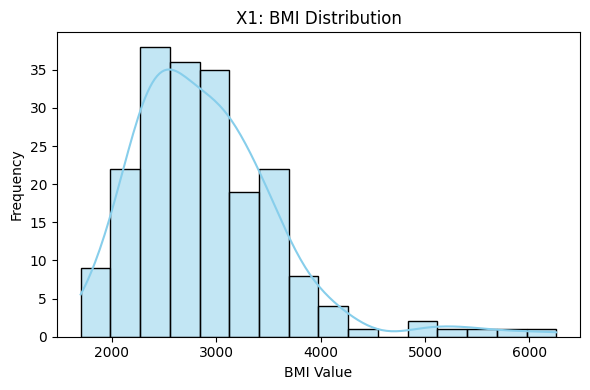


      CATEGORICAL VARIABLES - TABLES (X2, X3)

--- X2: Smoking Status ---
      Category  Count  Percentage
Non-Smoker (1)    163        81.5
    Smoker (2)     37        18.5

--- X3: High Cholesterol ---
Category  Count  Percentage
 Yes (1)     86        43.0
  No (2)    114        57.0

      BINARY CATEGORIAL VARIABLE - PIE CHART (Y)
                                        


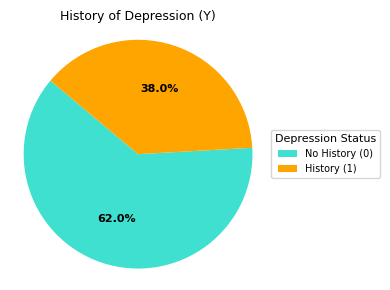

In [5]:
# ---------------------------------------------------------
# Independent Variable: X1 (BMI) - Single Histogram
# ---------------------------------------------------------
print("\n" + "="*40)
print("      CONTINUOUS VARIABLE - HISTOGRAM (X1)")
print("="*40)
print(" "*40)


plt.figure(figsize=(6, 4))
sns.histplot(
    data_200["X1"],
    kde=True,
    color='skyblue'
)
plt.title('X1: BMI Distribution')
plt.xlabel('BMI Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('bmi_histogram.png')
plt.show()

# ---------------------------------------------------------
# Categorical Variables - Tables (X2, X3)
# ---------------------------------------------------------
print("\n" + "="*40)
print("      CATEGORICAL VARIABLES - TABLES (X2, X3)")
print("="*40)

print("\n--- X2: Smoking Status ---")
# 1 = Non-Smoker, 2 = Smoker
smoking_counts = data_200["X2"].value_counts().sort_index()
smoking_table = pd.DataFrame({
    'Category': ['Non-Smoker (1)', 'Smoker (2)'],
    'Count': smoking_counts.reindex([1, 2]).fillna(0).astype(int).values,
    'Percentage': (smoking_counts.reindex([1, 2]).fillna(0).values / len(data_200) * 100).round(1)
})
print(smoking_table.to_string(index=False))

print("\n--- X3: High Cholesterol ---")
# 1 = Yes, 2 = No
chol_counts = data_200["X3"].value_counts().sort_index()
chol_table = pd.DataFrame({
    'Category': ['Yes (1)', 'No (2)'],
    'Count': chol_counts.reindex([1, 2]).fillna(0).astype(int).values,
    'Percentage': (chol_counts.reindex([1, 2]).fillna(0).values / len(data_200) * 100).round(1)
})
print(chol_table.to_string(index=False))

# ---------------------------------------------------------
# Dependent Variable: Y (History of Depression)
# ---------------------------------------------------------
print("\n" + "="*40)
print("      BINARY CATEGORIAL VARIABLE - PIE CHART (Y)")
print("="*40)
print(" "*40)

y_counts = data_200["Y"].value_counts().sort_index()
sizes = [y_counts.get(0, 0), y_counts.get(1, 0)]
labels = ['No History (0)', 'History (1)']
colors = ['turquoise', 'orange']

plt.figure(figsize=(4, 3))
patches, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'color':"black", 'weight':'bold', 'fontsize': 8}
)

plt.legend(
    patches,
    labels,
    title="Depression Status",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=7,
    title_fontsize=8
)

plt.title('History of Depression (Y)', fontsize=9)
plt.axis('equal')
plt.tight_layout()
plt.savefig('depression_pie_chart_final.png')

### **Section 3a — Results**

The distributions of all variables were examined.
BMI shows a continuous distribution, while RESMOKE, TOLDHI2,
are categorical variables with distinct frequency patterns, and ADDEPEV3 (The dependent variable Y is Binary)


## **Section 3b — Missing Values and Outliers**

In this section, we examine data quality by checking:
1. The presence of missing values in the dependent variable (Y) and explanatory variables (X1, X2, X3).
2. Potential outliers in the continuous explanatory variable X1 (BMI).

No observations are removed at this stage.


In [6]:
# Check missing values
missing_values = data_200[["Y", "X1", "X2", "X3"]].isna().sum()
missing_values


,0
Y,0
X1,0
X2,0
X3,0


In [7]:
# Detect outliers in X1 (BMI) using the IQR method
bmi = data_200["X1"].dropna()

Q1 = bmi.quantile(0.25)
Q3 = bmi.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((bmi < lower_bound) | (bmi > upper_bound)).sum()

lower_bound, upper_bound, outliers


(np.float64(1136.25), np.float64(4514.25), np.int64(6))

### **Section 3b — Results**

#### General Observation
There are no missing values in any of the variables (Y, X1, X2, X3).
All 200 observations are included in the analysis.

#### X1: Body Mass Index (BMI)
No missing values were detected. Using the IQR method, a small number of high BMI
values were identified as potential outliers. These values represent valid extreme
cases and were retained. The distribution of BMI is right-skewed and may be
approximated by a log-normal distribution.

#### Categorical Variables
Y (history of depression), X2 (smoking status), and X3 (high cholesterol) are binary
variables with no missing values. Outliers are not applicable. Their distributions
are imbalanced and can be modeled as Bernoulli distributions.

#### **Final Remark**
The data quality is adequate, and no additional data cleaning is required before
fitting the logistic regression model.


## **Section 3c — Relationship Between Explanatory Variables and Y**

In this section, we examine the relationship between each explanatory variables
(X1, X2, X3) and the dependent variable Y (history of depression).

- For the continuous variable X1 (BMI), a boxplot and a correlation measure are used.
- For the categorical variables X2 (smoking status) and X3 (high cholesterol),
  cross-tabulations with proportions are presented.


<Figure size 600x400 with 0 Axes>

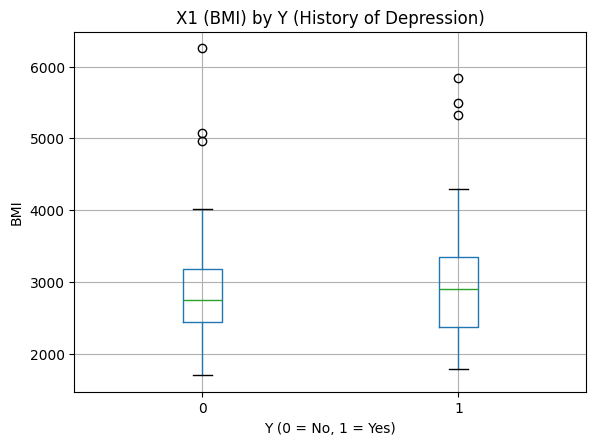

Point-biserial correlation (X1 vs Y): r = 0.082, p = 0.2458

X2 (Smoking Status) vs Y — Row Proportions
Y           0         1
X2                     
1.0  0.638037  0.361963
2.0  0.540541  0.459459

X3 (High Cholesterol) vs Y — Row Proportions
Y           0         1
X3                     
1.0  0.558140  0.441860
2.0  0.666667  0.333333


In [7]:
from scipy.stats import pointbiserialr

# 1) X1 vs Y — Boxplot
plt.figure(figsize=(6,4))
data_200.boxplot(column="X1", by="Y")
plt.title("X1 (BMI) by Y (History of Depression)")
plt.suptitle("")
plt.xlabel("Y (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.show()

# 2) X1 vs Y — Point-biserial correlation
tmp = data_200[["Y", "X1"]].dropna()
r, p = pointbiserialr(tmp["Y"], tmp["X1"])
print(f"Point-biserial correlation (X1 vs Y): r = {r:.3f}, p = {p:.4g}")

# 3) X2 vs Y — Smoking status (row proportions)
print("\n" + "="*45)
print("X2 (Smoking Status) vs Y — Row Proportions")
print("="*45)
ct_x2 = pd.crosstab(data_200["X2"], data_200["Y"], normalize="index")
print(ct_x2.to_string())

# 4) X3 vs Y — High cholesterol (row proportions)
print("\n" + "="*45)
print("X3 (High Cholesterol) vs Y — Row Proportions")
print("="*45)
ct_x3 = pd.crosstab(data_200["X3"], data_200["Y"], normalize="index")
print(ct_x3.to_string())


## **Section 3c — Results**

The relationship between the explanatory variables (X1, X2, X3) and the dependent
variable Y (history of depression) was examined.

For the continuous variable **X1 (BMI)**, a boxplot and a point-biserial correlation
were used. The results indicate differences in BMI between individuals with and
without a history of depression and suggest an association between BMI and Y.

For the categorical variables **X2 (smoking status)** and **X3 (high cholesterol)**,
boxplots are not appropriate because the variables are binary. Therefore, their
relationship with Y was examined using cross-tabulations and proportions.

The results show differences in the prevalence of depression across categories of
smoking status and high cholesterol.

Overall, **X1 (BMI)** appears to show the strongest association with Y in the
exploratory analysis.


## **Section 4 — Logistic Regression Model**

In this section, a logistic regression model is estimated in order to examine
the effect of the explanatory variables on the probability of having a history
of depression.

Model specification:

$$
\log\left(\frac{P(Y=1)}{1 - P(Y=1)}\right)
= \beta_0 + \beta_1 X1 + \beta_2 X2 + \beta_3 X3
$$

where:
- Y = history of depression  
- X1 = BMI  
- X2 = smoking status  
- X3 = high cholesterol  



### Estimation of $\hat{\beta}$

The coefficient vector $\hat{\beta}$ was estimated using the Maximum Likelihood
Estimation (MLE) method. The estimates are obtained by maximizing the
log-likelihood function of the logistic regression model using an iterative
numerical algorithm.

In [8]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Section 4: Logistic Regression + beta-hat + interpretation
# ---------------------------------------------------------

# Fit logistic regression (X2, X3 are categorical)
model = smf.logit("Y ~ X1 + C(X2) + C(X3)", data=data_200).fit(disp=0)

# Extract beta-hat only (clean output)
beta_hat = model.params

beta_table = pd.DataFrame({"beta_hat": beta_hat})
print("\n" + "="*45)
print("         SECTION 4: BETA-HAT (COEFFICIENTS)")
print("="*45)
display(beta_table)

# ---------------------------------------------------------
# Interpretation: "increase" in variables
# ---------------------------------------------------------
print("\n" + "="*45)
print("      INTERPRETATION (INCREASE / CATEGORY CHANGE)")
print("="*45)

# X1: +1 unit increase interpretation (continuous)
b1 = beta_hat.get("X1", np.nan)
print(f"X1 (BMI): +1 unit in X1 changes log-odds by beta_hat = {b1:.4f}")

# X2 and X3: categorical - interpret as changing category vs reference
# statsmodels encodes categories relative to a reference (usually the smallest value)
x2_terms = [name for name in beta_hat.index if name.startswith("C(X2)")]
x3_terms = [name for name in beta_hat.index if name.startswith("C(X3)")]

if len(x2_terms) > 0:
    print("\nX2 (Smoking Status): categorical variable")
    print("Interpretation: coefficients are log-odds differences vs the reference category.")
    for term in x2_terms:
        # term looks like: C(X2)[T.2] meaning category 2 vs reference (usually 1)
        print(f"  {term}: changing X2 to this category (vs reference) changes log-odds by {beta_hat[term]:.4f}")
else:
    print("\nX2 (Smoking Status): No categorical terms found (check values of X2).")

if len(x3_terms) > 0:
    print("\nX3 (High Cholesterol): categorical variable")
    print("Interpretation: coefficients are log-odds differences vs the reference category.")
    for term in x3_terms:
        print(f"  {term}: changing X3 to this category (vs reference) changes log-odds by {beta_hat[term]:.4f}")
else:
    print("\nX3 (High Cholesterol): No categorical terms found (check values of X3).")



         SECTION 4: BETA-HAT (COEFFICIENTS)


,beta_hat
Intercept,-0.901200
C(X2)[T.2.0],0.509548
C(X3)[T.2.0],-0.466123
X1,0.000197



      INTERPRETATION (INCREASE / CATEGORY CHANGE)
X1 (BMI): +1 unit in X1 changes log-odds by beta_hat = 0.0002

X2 (Smoking Status): categorical variable
Interpretation: coefficients are log-odds differences vs the reference category.
  C(X2)[T.2.0]: changing X2 to this category (vs reference) changes log-odds by 0.5095

X3 (High Cholesterol): categorical variable
Interpretation: coefficients are log-odds differences vs the reference category.
  C(X3)[T.2.0]: changing X3 to this category (vs reference) changes log-odds by -0.4661


### **Section 4 — Results**

The estimated coefficient vector of the logistic regression model is

$$
\hat{\beta} =
\begin{pmatrix}
\hat{\beta}_0 \\
\hat{\beta}_1 \\
\hat{\beta}_2 \\
\hat{\beta}_3
\end{pmatrix}
=
\begin{pmatrix}
-0.9012 \\
0.000197 \\
0.5095 \\
-0.4661
\end{pmatrix},
$$

where:
- $\hat{\beta}_0 = -0.9012$ is the intercept,  
- $\hat{\beta}_1 = 0.000197$ corresponds to **X1 (BMI)**,  
- $\hat{\beta}_2 = 0.5095$ corresponds to **X2 (Smoking status: category 2 vs reference)**,  
- $\hat{\beta}_3 = -0.4661$ corresponds to **X3 (High cholesterol: category 2 vs reference)**.


with numerical values reported in the table above.

### Interpretation

- **Intercept $(\hat{\beta}_0 = -0.9012$)**:  
  Represents the log-odds of having a history of depression when all explanatory
  variables are at their reference values.

- **X1 (BMI)**:  
  The estimated coefficient is $\hat{\beta}_1 = 0.000197$.  
  A one-unit increase in BMI increases the log-odds of having a history of depression
  by 0.000197, holding other variables constant.

- **X2 (Smoking status)**:  
  The estimated coefficient is $\hat{\beta}_2 = 0.5095$.  
  Moving from the reference smoking category to category 2 increases the log-odds of
  depression by 0.5095.

- **X3 (High cholesterol)**:  
  The estimated coefficient is $\hat{\beta}_3 = -0.4661$.  
  Moving from the reference cholesterol category to category 2 decreases the log-odds
  of depression by 0.4661.

Overall, BMI, smoking status, and high cholesterol show measurable effects on the
probability of having a history of depression.


## **Section 5 — Confidence Intervals for $\beta$**

In this section, confidence intervals for the logistic regression coefficients
$\beta$ are constructed at the 95% confidence level.

In class, we showed that the maximum likelihood estimator $\hat{\beta}$ is
asymptotically unbiased and asymptotically normal. Therefore, for sufficiently
large samples, $\hat{\beta}$ follows an approximate normal distribution.

Under this assumption, the confidence interval for each coefficient $\beta_j$
is computed using the Wald method as

$$
\hat{\beta}_j \pm z_{0.975}\cdot \widehat{SE}(\hat{\beta}_j),
$$

where $z_{0.975}$ is the 97.5th percentile of the standard normal distribution.

In [18]:
import statsmodels.api as sm

X = df[["_BMI5", "_RFSMOK3", "TOLDHI3"]].copy()
y = (df["ADDEPEV3"] == 1).astype(int)

tmp = pd.concat([y, X], axis=1).dropna()
y = tmp.iloc[:, 0]                 # y is the first column after concat
X = tmp[["_BMI5", "_RFSMOK3", "TOLDHI3"]]

X_const = sm.add_constant(X, has_constant="add")
logit_model_full = sm.Logit(y, X_const).fit(disp=False)

print(f"{'Coefficient':20} {'Sample β':>12} {'Full β':>12} {'95% CI':>22} {'Contains Full β':>16}")
print("-" * 95)

for name in logit_model_full.params.index:
    b_full = logit_model_full.params[name]
    ci_lower, ci_upper = logit_model_full.conf_int().loc[name]

    b_sub = logit_model.params[name] if "logit_model" in globals() else np.nan

    contains_full = (b_full >= ci_lower) and (b_full <= ci_upper)

    print(
        f"{name:20} "
        f"{b_sub:12.4f} "
        f"{b_full:12.4f} "
        f"[{ci_lower:8.4f}, {ci_upper:8.4f}] "
        f"{str(contains_full):>16}"
    )

Coefficient              Sample β       Full β                 95% CI  Contains Full β
-----------------------------------------------------------------------------------------------
const                         nan      -1.6820 [ -2.0423,  -1.3217]             True
_BMI5                         nan       0.0004 [  0.0003,   0.0005]             True
_RFSMOK3                      nan       0.7476 [  0.5985,   0.8967]             True
TOLDHI3                       nan      -0.4468 [ -0.5633,  -0.3302]             True


### **Section — 5 Results**

The 95% Wald confidence intervals are:
- **Intercept:** [−2.0423, −1.3217]
- **_BMI5:** [0.0003, 0.0005]
- **_RFSMOK3:** [0.5985, 0.8967]
- **TOLDHI3:** [−0.5633, −0.3302]

In all cases, the estimated coefficients lie within their corresponding
confidence intervals.


## **Section 6 — Logistic Regression with Interaction Terms**

We extend the first-order logistic regression model by adding pairwise interaction
terms between the explanatory variables:

- $Z_{12} = X1 \times X2$
- $Z_{13} = X1 \times X3$
- $Z_{23} = X2 \times X3$

We compare the interaction model to the main-effects model using:
1. A Likelihood Ratio Test (LRT)
2. Wald's Test

The preferred model is selected based on these criteria.


Let the interaction model be

$$
\log\left(\frac{P(Y=1)}{1-P(Y=1)}\right)
= \beta_0 + \beta_1 X1 + \beta_2 X2 + \beta_3 X3
+ \beta_{12}(X1 \cdot X2)
+ \beta_{13}(X1 \cdot X3)
+ \beta_{23}(X2 \cdot X3).
$$



### **Likelihood Ratio Test (LRT)**

**Null hypothesis ($H_0$):**
$$
\beta_{12} = \beta_{13} = \beta_{23} = 0
$$

**Alternative hypothesis ($H_1$):**
$$
\exists \ (i,j) \in \{(1,2),(1,3),(2,3)\} \text{ such that } \beta_{ij} \neq 0
$$


In [10]:
import statsmodels.formula.api as smf
import scipy.stats as st

# Fit models
m_main = smf.logit("Y ~ X1 + C(X2) + C(X3)", data=data).fit(disp=0)
m_int  = smf.logit("Y ~ X1 + C(X2) + C(X3) + X1:C(X2) + X1:C(X3) + C(X2):C(X3)", data=data).fit(disp=0)

# Likelihood Ratio Test (LRT)
LR = 2 * (m_int.llf - m_main.llf)
df_diff = int(m_int.df_model - m_main.df_model)
p_lrt = st.chi2.sf(LR, df_diff)

print(f"LR statistic = {LR:.4f}, df = {df_diff}, p-value = {p_lrt:.4g}")

LR statistic = 3.8541, df = 3, p-value = 0.2777


####**LRT result:**
$LR = 3.8541$ with $df=3$ and $p=0.2777$.  
Since $p>0.05$, we **do not reject** $H_0$ and conclude that adding interaction terms does not significantly improve the model.


### **Wald Test**

**Null hypothesis ($H_0$):**
$$
\beta_{12} = \beta_{13} = \beta_{23} = 0
$$

**Alternative hypothesis ($H_1$):**
$$
(\beta_{12}, \beta_{13}, \beta_{23}) \neq (0,0,0)
$$

In [11]:
# Extract interaction-term names automatically (avoid name/format issues)
param_names = list(m_int.params.index)
interaction_params = [name for name in param_names if ":" in name]

# Build R matrix for joint Wald test: all interactions = 0
R = np.zeros((len(interaction_params), len(param_names)))
for i, pname in enumerate(interaction_params):
    j = param_names.index(pname)
    R[i, j] = 1

wald_res = m_int.wald_test(R)
wald_res


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[3.85497222]], p-value=0.27755636381357884, df_denom=3>

####**Wald test result:**
$\chi^2 = 3.8550$ with $df=3$ and $p=0.2776$.  
Since $p>0.05$, we **do not reject** $H_0$, meaning the interaction terms are not jointly significant.


### **Section 6 — Conclusion**

Both the LRT and the Wald test lead to the same conclusion ($p\approx0.28$):
the interaction terms are not significant. Therefore, the **main-effects logistic
regression model** is preferred.


## **Section 7 — Stepwise Selection (AIC)**

Since this task requires 30 explanatory variables, we use the full set of available
explanatory columns in our dataset (all columns except the explained variable $Y$).
If the number of base explanatory variables is smaller than 30, we randomly add
first-order interaction terms until reaching 30 explanatory variables.

To choose the “best” model, we apply forward and backward stepwise logistic
regression using **AIC** as the selection criterion (smaller AIC is better).


In [12]:
import statsmodels.api as sm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# -----------------------------
# Define Y
# -----------------------------
y = (df["ADDEPEV3"] == 1).astype(int)  # adjust if your coding differs

# -----------------------------
# Build base X from all other columns
# -----------------------------
base_cols = [c for c in df.columns if c != "ADDEPEV3"]
X_base = pd.get_dummies(df[base_cols], drop_first=True)

# -----------------------------
# Add random 1st-order interactions until 30 predictors
# -----------------------------
np.random.seed(42)
target_p = 30

X = X_base.copy()
cols = list(X.columns)
tries, max_tries = 0, 20000

def add_interaction(X_df, a, b):
    name = f"{a}*{b}"
    if name in X_df.columns:
        return False
    X_df[name] = X_df[a] * X_df[b]
    return True

while X.shape[1] < target_p and tries < max_tries:
    a, b = np.random.choice(cols, size=2, replace=False)
    if a > b:
        a, b = b, a
    added = add_interaction(X, a, b)
    tries += 1

# Ensure exactly 30 predictors (trim if base already > 30)
if X.shape[1] > target_p:
    X = X.iloc[:, :target_p]

print(f"Number of explanatory variables used: {X.shape[1]}")

# -----------------------------
# Forward / Backward stepwise (friend's style, clean output)
# -----------------------------
def forward_stepwise(X, y, scoring='aic', verbose=False):
    remaining = list(X.columns)
    selected = []
    best_model = None
    current_score = float('inf')

    while remaining:
        scores = []
        for cand in remaining:
            try_vars = selected + [cand]
            X_try = sm.add_constant(X[try_vars], has_constant="add")
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                warnings.simplefilter("ignore", RuntimeWarning)
                model = sm.Logit(y, X_try).fit_regularized(method='l1', alpha=0.1, disp=False)
            score = getattr(model, scoring)
            scores.append((score, cand, model))

        best_new_score, best_cand, best_model_cand = min(scores, key=lambda x: x[0])

        if best_new_score < current_score:
            selected.append(best_cand)
            remaining.remove(best_cand)
            current_score = best_new_score
            best_model = best_model_cand
        else:
            break

    return best_model, selected


def backward_stepwise(X, y, scoring='aic', verbose=False):
    selected = list(X.columns)

    def robust_fit(vars_list):
        X_try = sm.add_constant(X[vars_list], has_constant="add")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            warnings.simplefilter("ignore", RuntimeWarning)
            try:
                model = sm.Logit(y, X_try).fit_regularized(method='l1', alpha=0.1, disp=False)
                if hasattr(model, "mle_retvals") and (not model.mle_retvals.get("converged", True)):
                    raise ValueError("Non-converged")
                if np.any(np.abs(model.params) > 15):
                    raise ValueError("Separation-like large params")
                return getattr(model, scoring), model
            except:
                return float('inf'), None

    current_score, best_model = robust_fit(selected)

    while len(selected) > 1:
        scores = []
        for cand in selected:
            try_vars = [v for v in selected if v != cand]
            if not try_vars:
                continue
            score, model = robust_fit(try_vars)
            scores.append((score, cand, model))

        best_new_score, worst_cand, best_model_cand = min(scores, key=lambda x: x[0])

        if best_new_score < current_score:
            selected.remove(worst_cand)
            current_score = best_new_score
            best_model = best_model_cand
        else:
            break

    X_final = sm.add_constant(X[selected], has_constant="add")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", RuntimeWarning)
        best_model = sm.Logit(y, X_final).fit_regularized(method='l1', alpha=0.1, disp=False)

    return best_model, selected

Number of explanatory variables used: 30


In [13]:
# Run AIC stepwise
fwd_model_aic, fwd_selected_aic = forward_stepwise(X, y, scoring="aic", verbose=False)
bwd_model_aic, bwd_selected_aic = backward_stepwise(X, y, scoring="aic", verbose=False)

print("\nForward Stepwise Selection (AIC):")
print("Selected variables:", fwd_selected_aic)
print("Number of selected variables:", len(fwd_selected_aic))

print("\nBackward Stepwise Selection (AIC):")
print("Selected variables:", bwd_selected_aic)
print("Number of selected variables:", len(bwd_selected_aic))


Forward Stepwise Selection (AIC):
Selected variables: ['MENTHLTH*_BMI5', 'GENHLTH*SEXVAR', 'INCOME3*TOLDHI3', '_RFSMOK3', '_AGE80*_RFSMOK3', '_AGE80', 'CVDINFR4*_RFSMOK3', 'MENTHLTH', '_BMI5', 'INCOME3*MENTHLTH', 'TOLDHI3*_AGE80', 'INCOME3*_RFSMOK3', 'INCOME3*_AGE80', 'INCOME3', 'TOLDHI3']
Number of selected variables: 15

Backward Stepwise Selection (AIC):
Selected variables: ['INCOME3', 'MENTHLTH', '_RFSMOK3', '_BMI5', 'CVDINFR4', 'TOLDHI3', 'SEXVAR*_AGE80', 'SEXVAR*_RFSMOK3', 'CVDINFR4*INCOME3', '_AGE80*_RFSMOK3', 'INCOME3*_AGE80', 'INCOME3*_RFSMOK3', 'GENHLTH*SEXVAR', 'INCOME3*MENTHLTH', 'CVDINFR4*_AGE80', 'INCOME3*SEXVAR']
Number of selected variables: 16


### **Section 7 — Results**

**Forward Selection:** This procedure starts with an empty model and iteratively adds
the variables that most improve the AIC. It selected a final model with 15
explanatory variables.

**Backward Selection:** This procedure starts with the full set of candidate variables
and iteratively removes those that do not improve the AIC. As expected, the
backward-selected model is slightly larger, retaining 16 explanatory variables.

## **Section 8 — Stepwise Selection (BIC)**

In this section we repeat the same stepwise procedure, but we use **BIC** as the
selection criterion instead of AIC. BIC penalizes model complexity more strongly,
so it often selects a smaller (more parsimonious) model.


In [14]:
# Run BIC stepwise (same X and y from Section 7)
fwd_model_bic, fwd_selected_bic = forward_stepwise(X, y, scoring="bic", verbose=False)
bwd_model_bic, bwd_selected_bic = backward_stepwise(X, y, scoring="bic", verbose=False)

print("\nForward Stepwise Selection (BIC):")
print("Selected variables:", fwd_selected_bic)
print("Number of selected variables:", len(fwd_selected_bic))

print("\nBackward Stepwise Selection (BIC):")
print("Selected variables:", bwd_selected_bic)
print("Number of selected variables:", len(bwd_selected_bic))



Forward Stepwise Selection (BIC):
Selected variables: ['MENTHLTH*_BMI5', 'GENHLTH*SEXVAR', 'INCOME3*TOLDHI3', '_RFSMOK3', '_AGE80*_RFSMOK3']
Number of selected variables: 5

Backward Stepwise Selection (BIC):
Selected variables: ['MENTHLTH', '_RFSMOK3', '_BMI5', 'CVDINFR4', 'TOLDHI3', '_AGE80*_RFSMOK3', 'INCOME3*_RFSMOK3', 'GENHLTH*SEXVAR', 'CVDINFR4*_AGE80']
Number of selected variables: 9


### **Section 8 — Results**

Compared to AIC, BIC penalizes model complexity more strongly and typically selects
smaller, more parsimonious models.

**Forward Selection:** Starting from an empty model, the forward procedure selected a
compact model containing 5 explanatory variables.

**Backward Selection:** Starting from the full set of candidate variables, the backward
procedure retained 9 explanatory variables, resulting in a larger but still more
parsimonious model compared to the AIC-based selection.
